In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [ ]:
X = train_df.drop(columns=[col for col in train_df.columns if 'BlendProperty' in col])
y = train_df[[col for col in train_df.columns if 'BlendProperty' in col]]
test_df = test_df[X.columns]

In [ ]:
X.fillna(0, inplace=True)
test_df.fillna(0, inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test_df)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

rf_models = []
rf_mae_scores = []

for i in range(y.shape[1]):
    print(f"Training Random Forest for {y.columns[i]}")

    X_train, X_val, y_train, y_val = train_test_split(X_scaled, y.iloc[:, i], test_size=0.2, random_state=42)

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    val_preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, val_preds)
    rf_mae_scores.append(mae)

    rf_models.append(model)

print("✅ All Random Forest models trained.")


Training Random Forest for BlendProperty1
Training Random Forest for BlendProperty2
Training Random Forest for BlendProperty3
Training Random Forest for BlendProperty4
Training Random Forest for BlendProperty5
Training Random Forest for BlendProperty6
Training Random Forest for BlendProperty7
Training Random Forest for BlendProperty8
Training Random Forest for BlendProperty9
Training Random Forest for BlendProperty10
✅ All Random Forest models trained.


In [ ]:
rf_mae_scores = []

for i in range(y.shape[1]):
    ...
    mae = mean_absolute_error(y_val, val_preds)
    rf_mae_scores.append(mae)


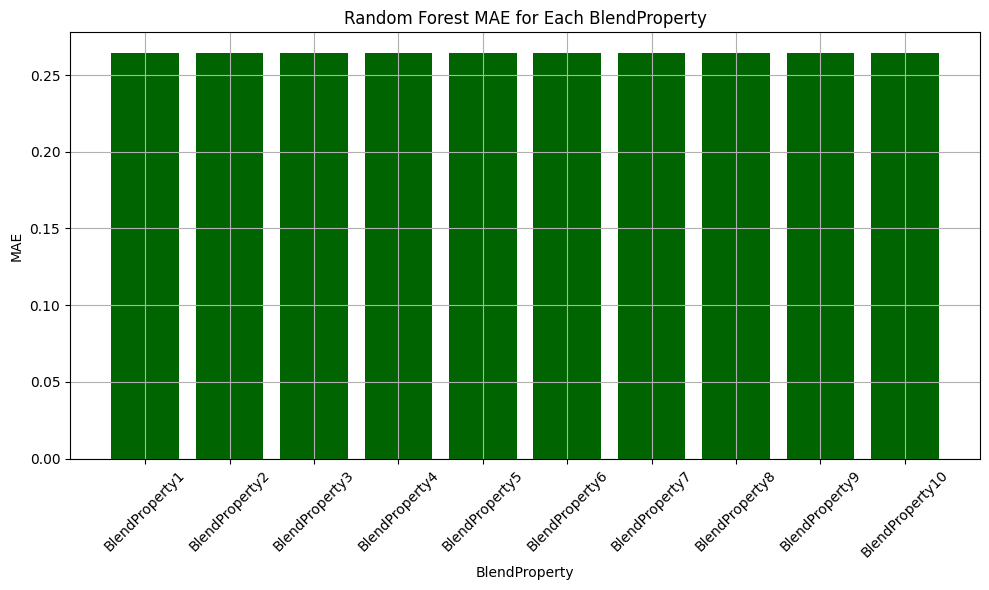

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(y.columns, rf_mae_scores, color='darkgreen')
plt.title("Random Forest MAE for Each BlendProperty")
plt.xlabel("BlendProperty")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()


/tmp/ipython-input-8-3397615139.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_models[0].feature_importances_, y=X.columns, palette="Greens_r")


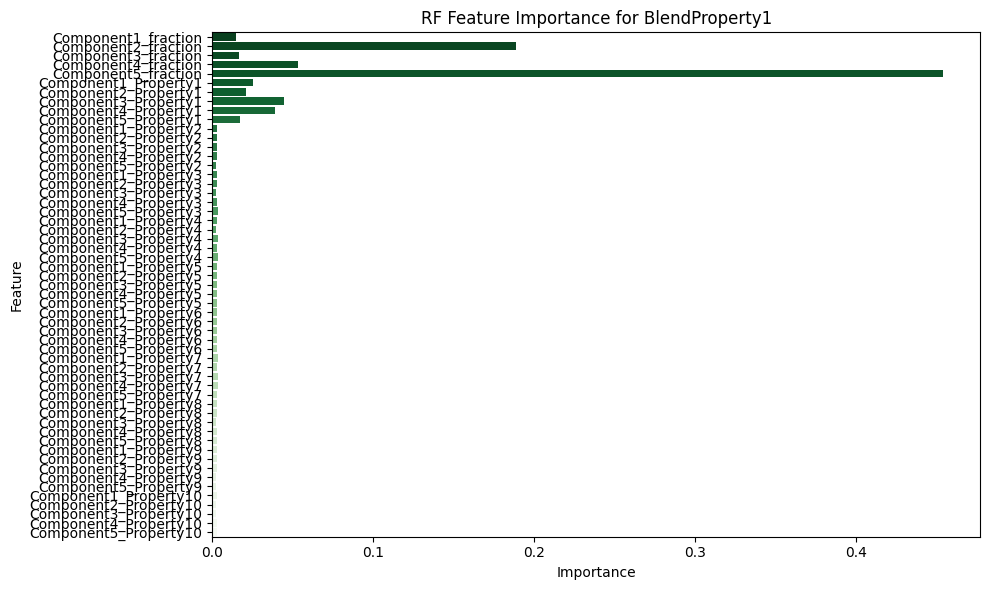

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=rf_models[0].feature_importances_, y=X.columns, palette="Greens_r")
plt.title("RF Feature Importance for BlendProperty1")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

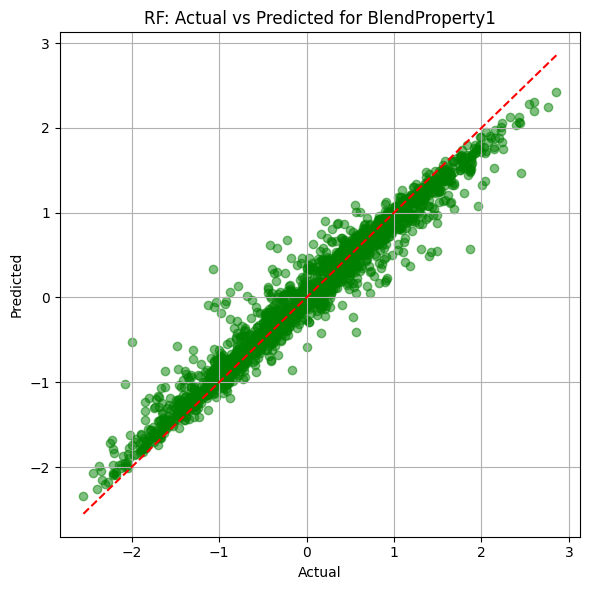

In [ ]:
y_true_rf = y.iloc[:, 0]
y_pred_rf = rf_models[0].predict(X_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(y_true_rf, y_pred_rf, alpha=0.5, color='green')
plt.plot([y_true_rf.min(), y_true_rf.max()], [y_true_rf.min(), y_true_rf.max()], '--r')
plt.title(f"RF: Actual vs Predicted for {y.columns[0]}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Assuming you have a list of trained Random Forest models
rg_preds = np.column_stack([model.predict(test_scaled) for model in rf_models])

# Save the predictions to a .npy file
np.save("rg_preds.npy", rg_preds)


In [ ]:
rf_submission = pd.DataFrame(rf_test_preds, columns=y.columns)
rf_submission.insert(0, 'ID', range(1, len(test_df) + 1))
rf_submission.to_csv("submission_rf.csv", index=False)
print("📁 submission_rf.csv saved!")

📁 submission_rf.csv saved!


In [ ]:
nn_models = []
nn_mae_scores = []

for i in range(y.shape[1]):
    print(f"🧠 Training NN for {y.columns[i]}")

    X_train, X_val, y_train, y_val = train_test_split(X_scaled, y.iloc[:, i], test_size=0.2, random_state=42)

    model = MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu',
                         solver='adam', max_iter=1000, random_state=42)

    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)

    mae = mean_absolute_error(y_val, val_preds)
    nn_mae_scores.append(mae)
    nn_models.append(model)

    print(f"✅ NN MAE: {mae:.5f}")

🧠 Training NN for BlendProperty1
✅ NN MAE: 0.28131
🧠 Training NN for BlendProperty2
✅ NN MAE: 0.25404
🧠 Training NN for BlendProperty3
✅ NN MAE: 0.30381
🧠 Training NN for BlendProperty4
✅ NN MAE: 0.28304
🧠 Training NN for BlendProperty5
✅ NN MAE: 0.60613
🧠 Training NN for BlendProperty6
✅ NN MAE: 0.30260
🧠 Training NN for BlendProperty7
✅ NN MAE: 0.30288
🧠 Training NN for BlendProperty8
✅ NN MAE: 0.30497
🧠 Training NN for BlendProperty9
✅ NN MAE: 0.32465
🧠 Training NN for BlendProperty10
✅ NN MAE: 0.26748


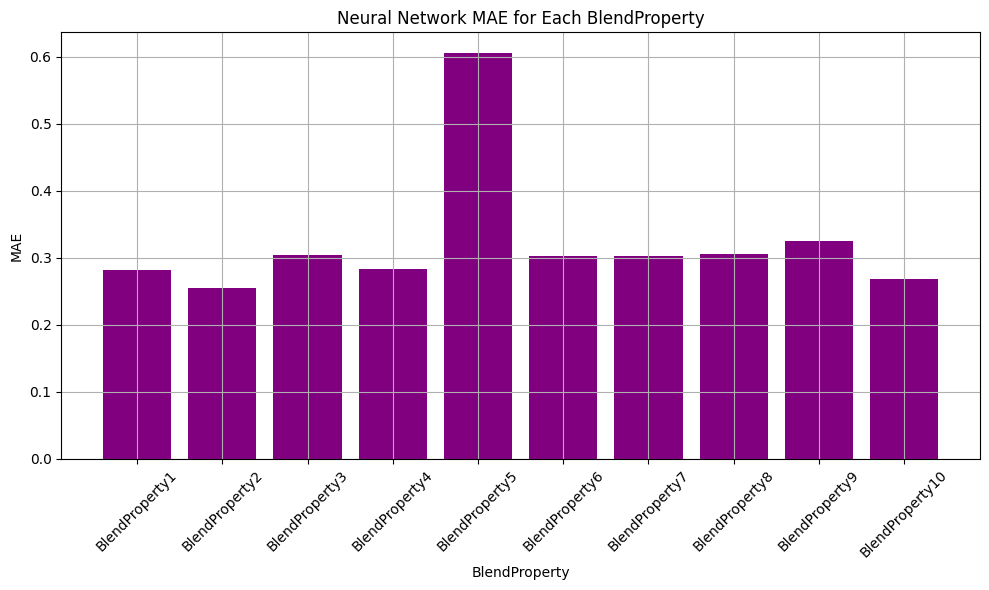

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(y.columns, nn_mae_scores, color='purple')
plt.title("Neural Network MAE for Each BlendProperty")
plt.xlabel("BlendProperty")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

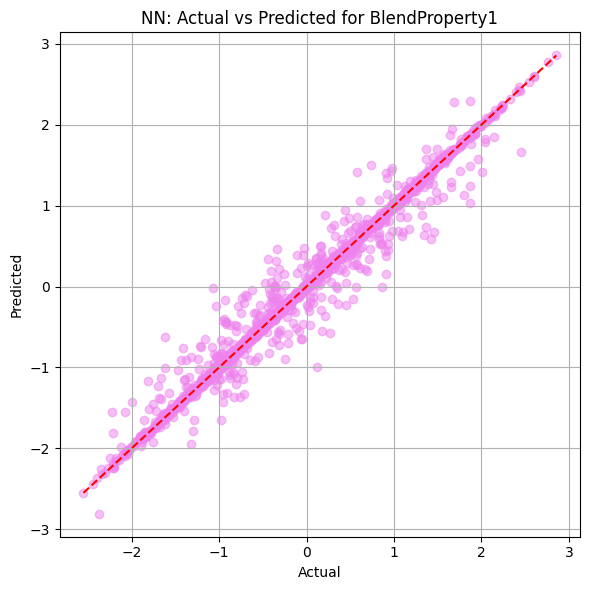

In [ ]:
y_true_nn = y.iloc[:, 0]
y_pred_nn = nn_models[0].predict(X_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(y_true_nn, y_pred_nn, alpha=0.5, color='violet')
plt.plot([y_true_nn.min(), y_true_nn.max()], [y_true_nn.min(), y_true_nn.max()], '--r')
plt.title(f"NN: Actual vs Predicted for {y.columns[0]}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Assuming nn_models is a list of trained neural network models (e.g., Keras or PyTorch models)
nn_test_preds = np.column_stack([model.predict(test_scaled) for model in nn_models])

# Save to .npy file
np.save("nn_test_preds.npy", nn_test_preds)


In [ ]:
nn_submission = pd.DataFrame(nn_test_preds, columns=y.columns)
nn_submission.insert(0, 'ID', range(1, len(test_df) + 1))
nn_submission.to_csv("submission_nn.csv", index=False)
print("📁 submission_nn.csv saved!")

📁 submission_nn.csv saved!
